# 05. OTM ma'lumotlarini tushunish (Data Understanding)

Manba: `data/processed/final_otm_2026.csv` — mandat.uzbmb.uz dan yig'ilgan, har bir qator bitta OTM × yo'nalish × ta'lim tili × ta'lim shakli kombinatsiyasi: kvotalar soni va o'tish ballari.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/processed/final_otm_2026.csv')
df.head()

,Unnamed: 0,hudud,otm_nomi,yunalish_nomi,talim_tili,talim_shakli,grant_kvota_soni,shartnoma_kvota_soni,grant_bali,shartnoma_bali
0,0,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Amaliy matematika,O'zbekcha,Kunduzgi,2,20,165.9,110.3
1,1,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Amaliy matematika,O'zbekcha,Kechki,0,13,0.0,61.9
2,2,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Amaliy matematika,Русский,Kunduzgi,1,4,167.8,59.8
3,3,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Amaliy matematika,Qoraqalpoq,Kunduzgi,1,24,170.1,64.3
4,4,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Amaliy matematika,Qoraqalpoq,Kechki,0,12,0.0,56.9


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

## 1. Umumiy tuzilma

In [4]:
print(f"Qatorlar: {df.shape[0]:,}  |  Ustunlar: {df.shape[1]}")
df.info(memory_usage='deep')

Qatorlar: 5,712  |  Ustunlar: 10
<class 'pandas.DataFrame'>
RangeIndex: 5712 entries, 0 to 5711
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            5712 non-null   int64  
 1   hudud                 5712 non-null   str    
 2   otm_nomi              5712 non-null   str    
 3   yunalish_nomi         5712 non-null   str    
 4   talim_tili            5712 non-null   str    
 5   talim_shakli          5712 non-null   str    
 6   grant_kvota_soni      5712 non-null   int64  
 7   shartnoma_kvota_soni  5712 non-null   int64  
 8   grant_bali            5712 non-null   float64
 9   shartnoma_bali        5712 non-null   float64
dtypes: float64(2), int64(3), str(5)
memory usage: 2.3 MB


In [5]:
# `Unnamed: 0` — CSV ga index=False siz saqlangan eski index
print('Unnamed: 0 == 0..n-1:', (df['Unnamed: 0'] == np.arange(len(df))).all())

Unnamed: 0 == 0..n-1: True


In [6]:
pd.DataFrame({
    'tur': df.dtypes.astype(str),
    'noyob_qiymatlar': df.nunique(),
    'misol': df.iloc[0],
})

,tur,noyob_qiymatlar,misol
Unnamed: 0,int64,5712,0
hudud,str,14,Qoraqalpog‘iston Respublikasi
otm_nomi,str,105,Nukus davlat pedagogika instituti
yunalish_nomi,str,1096,Amaliy matematika
talim_tili,str,7,O'zbekcha
talim_shakli,str,4,Kunduzgi
grant_kvota_soni,int64,93,2
shartnoma_kvota_soni,int64,188,20
grant_bali,float64,997,165.9
shartnoma_bali,float64,1049,110.3


| Ustun | Ma'nosi | Bashorat paytida ma'lummi? |
|---|---|---|
| `hudud` | OTM joylashgan viloyat | Ha |
| `otm_nomi` | Oliy ta'lim muassasasi | Ha |
| `yunalish_nomi` | Ta'lim yo'nalishi | Ha |
| `talim_tili` | Ta'lim tili | Ha |
| `talim_shakli` | Kunduzgi / Kechki / Masofaviy / Dual | Ha |
| `grant_kvota_soni` | Davlat granti o'rinlari | Ha (qabuldan oldin e'lon qilinadi) |
| `shartnoma_kvota_soni` | To'lov-shartnoma o'rinlari | Ha |
| `grant_bali` | Grant bo'yicha o'tish bali | **Yo'q — maqsadli o'zgaruvchi** |
| `shartnoma_bali` | Shartnoma bo'yicha o'tish bali | **Yo'q — maqsadli o'zgaruvchi** |

## 2. Ma'lumotlar sifati: bo'sh qiymatlar va takrorlar

In [7]:
pd.DataFrame({
    'bosh_soni': df.isna().sum(),
    'bosh_foizi': (df.isna().mean() * 100).round(2),
})

,bosh_soni,bosh_foizi
Unnamed: 0,0,0.0
hudud,0,0.0
otm_nomi,0,0.0
yunalish_nomi,0,0.0
talim_tili,0,0.0
talim_shakli,0,0.0
grant_kvota_soni,0,0.0
shartnoma_kvota_soni,0,0.0
grant_bali,0,0.0
shartnoma_bali,0,0.0


Bo'sh qiymat yo'q — lekin bu `03`-bosqichda `fillna(0)` qilingani uchun. Demak **0 ball** "o'tish bali yo'q" degani, haqiqiy ball emas. Buni 4-bo'limda tekshiramiz.

In [8]:
kalit = ['otm_nomi', 'yunalish_nomi', 'talim_tili', 'talim_shakli']
asosiy = df.drop(columns='Unnamed: 0')

print('To\'liq takrorlangan qatorlar:', asosiy.duplicated().sum())
print('Kalit bo\'yicha takrorlar:     ', asosiy.duplicated(kalit).sum())

To'liq takrorlangan qatorlar: 13
Kalit bo'yicha takrorlar:      14


In [9]:
# Kalit bir xil, lekin qiymatlari farq qiladigan qatorlar
asosiy[asosiy.duplicated(kalit, keep=False) & ~asosiy.duplicated(keep=False)]

,hudud,otm_nomi,yunalish_nomi,talim_tili,talim_shakli,grant_kvota_soni,shartnoma_kvota_soni,grant_bali,shartnoma_bali
5173,Toshkent shahri,Toshkent davlat iqtisodiyot universiteti,Davlat auditi,O'zbekcha,Kunduzgi,0,150,0.0,176.4
5174,Toshkent shahri,Toshkent davlat iqtisodiyot universiteti,Davlat auditi,O'zbekcha,Kunduzgi,0,9,0.0,176.4


In [10]:
# To'liq takrorlarning namunasi
asosiy[asosiy.duplicated(keep=False)].sort_values(kalit).head(6)

,hudud,otm_nomi,yunalish_nomi,talim_tili,talim_shakli,grant_kvota_soni,shartnoma_kvota_soni,grant_bali,shartnoma_bali
1863,Buxoro viloyati,Buxoro davlat pedagogika instituti,Xorijiy til va adabiyoti: ingliz tili (Peshku tumani),O'zbekcha,Kunduzgi,2,0,186.8,0.0
1871,Buxoro viloyati,Buxoro davlat pedagogika instituti,Xorijiy til va adabiyoti: ingliz tili (Peshku tumani),O'zbekcha,Kunduzgi,2,0,186.8,0.0
1864,Buxoro viloyati,Buxoro davlat pedagogika instituti,Xorijiy til va adabiyoti: ingliz tili (Romitan tumani),O'zbekcha,Kunduzgi,3,0,183.9,0.0
1872,Buxoro viloyati,Buxoro davlat pedagogika instituti,Xorijiy til va adabiyoti: ingliz tili (Romitan tumani),O'zbekcha,Kunduzgi,3,0,183.9,0.0
1865,Buxoro viloyati,Buxoro davlat pedagogika instituti,Xorijiy til va adabiyoti: ingliz tili (Shofirkon tumani),O'zbekcha,Kunduzgi,1,0,186.8,0.0
1873,Buxoro viloyati,Buxoro davlat pedagogika instituti,Xorijiy til va adabiyoti: ingliz tili (Shofirkon tumani),O'zbekcha,Kunduzgi,1,0,186.8,0.0


## 3. Kategorial ustunlar

In [11]:
for col in ['hudud', 'talim_tili', 'talim_shakli']:
    print(f"--- {col}: {df[col].nunique()} ta ---")
    print(df[col].value_counts().to_string(), end='\n\n')

--- hudud: 14 ta ---
hudud
Toshkent shahri                  1249
Qoraqalpog‘iston Respublikasi     732
Toshkent viloyati                 498
Farg‘ona viloyati                 475
Samarqand viloyati                460
Surxondaryo viloyati              392
Buxoro viloyati                   376
Andijon viloyati                  359
Qashqadaryo viloyati              323
Namangan viloyati                 218
Xorazm viloyati                   192
Navoiy viloyati                   153
Jizzax viloyati                   152
Sirdaryo viloyati                 133

--- talim_tili: 7 ta ---
talim_tili
O'zbekcha     4438
Русский        921
Qoraqalpoq     314
Qozoq           19
Tadjik          14
Turkman          3
Qirg'iz          3

--- talim_shakli: 4 ta ---
talim_shakli
Kunduzgi     4339
Kechki        900
Masofaviy     444
Dual           29



In [12]:
print('OTM lar soni:      ', df['otm_nomi'].nunique())
print('Yo\'nalishlar soni: ', df['yunalish_nomi'].nunique())
df['otm_nomi'].value_counts().head(10)

OTM lar soni:       105
Yo'nalishlar soni:  1096


otm_nomi
Qoraqalpoq davlat universiteti                               239
Farg‘ona davlat universiteti                                 175
Buxoro davlat universiteti                                   130
Farg‘ona davlat texnika universiteti                         123
Nukus davlat pedagogika instituti                            121
Navoiy davlat univeristeti                                   121
O‘zbekiston davlat jismoniy tarbiya va sport universiteti    118
Chirchiq davlat pedagogika universiteti                      116
O‘zbekiston Milliy universiteti                              116
Urganch davlat universiteti                                  112
Name: count, dtype: int64

### Yo'nalish nomlaridagi qo'shimchalar

Ba'zi yo'nalishlar nomida qavs ichida tuman (maqsadli kvota) yoki ixtisoslik bor, masalan `Biologiya (Boʻzatov tumani)`.

In [13]:
qavs = df['yunalish_nomi'].str.contains(r'\(', regex=True)
tuman = df['yunalish_nomi'].str.contains('tumani', regex=False)
print('Qavsli nomlar:  ', qavs.sum())
print('Tuman kvotalari:', tuman.sum())

df['asosiy_yunalish'] = df['yunalish_nomi'].str.replace(r'\s*\(.*\)\s*$', '', regex=True).str.strip()
print('Qavssiz noyob yo\'nalishlar:', df['asosiy_yunalish'].nunique())
df.loc[qavs, 'yunalish_nomi'].sample(8, random_state=0)

Qavsli nomlar:   934
Tuman kvotalari: 756
Qavssiz noyob yo'nalishlar: 342


3548    Ona tili va adabiyoti: rus tili (Nurobod tumani)
1610                     Davolash ishi (Beshariq tumani)
4394                        Davolash ishi (Boʻka tumani)
4425            Oliy hamshiralik ishi (Ohangaron tumani)
1646                   Pediatriya ishi (Oltiariq tumani)
75                    Musiqa taʼlimi (Qoʻngʻirot tumani)
2886                        Davolash ishi (Kitob tumani)
4443                      Pediatriya ishi (Boʻka tumani)
Name: yunalish_nomi, dtype: str

## 4. Kvotalar va o'tish ballari

In [14]:
df[['grant_kvota_soni', 'shartnoma_kvota_soni', 'grant_bali', 'shartnoma_bali']].describe().round(1)

,grant_kvota_soni,shartnoma_kvota_soni,grant_bali,shartnoma_bali
count,5712.0,5712.0,5712.0,5712.0
mean,5.4,27.0,83.0,72.0
std,12.2,38.3,75.7,47.4
min,0.0,0.0,0.0,0.0
25%,0.0,5.0,0.0,56.8
50%,1.0,20.0,78.6,60.9
75%,5.0,34.0,161.4,98.8
max,347.0,948.0,191.5,187.9


### 0 qiymatning ma'nosi

Kvota 0 bo'lsa ball ham 0 bo'lishi kerak — tekshiramiz.

In [15]:
print('Grant:')
print(pd.crosstab(df['grant_kvota_soni'] == 0, df['grant_bali'] == 0,
                  rownames=['kvota=0'], colnames=['bal=0']), end='\n\n')
print('Shartnoma:')
print(pd.crosstab(df['shartnoma_kvota_soni'] == 0, df['shartnoma_bali'] == 0,
                  rownames=['kvota=0'], colnames=['bal=0']))

Grant:
bal=0    False  True 
kvota=0              
False     3382      0
True         0   2330

Shartnoma:
bal=0    False  True 
kvota=0              
False     4729      0
True         0    983


In [16]:
hech_kvota_yoq = (df['grant_kvota_soni'] == 0) & (df['shartnoma_kvota_soni'] == 0)
print('Grant ham, shartnoma ham yo\'q qatorlar:', hech_kvota_yoq.sum())
df[hech_kvota_yoq].head()

Grant ham, shartnoma ham yo'q qatorlar: 151


,Unnamed: 0,hudud,otm_nomi,yunalish_nomi,talim_tili,talim_shakli,grant_kvota_soni,shartnoma_kvota_soni,grant_bali,shartnoma_bali,asosiy_yunalish
12,12,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Biologiya (Boʻzatov tumani),O'zbekcha,Kunduzgi,0,0,0.0,0.0,Biologiya
20,20,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Boshlangʻich taʼlim (Moʻynoq tumani),O'zbekcha,Kunduzgi,0,0,0.0,0.0,Boshlangʻich taʼlim
23,23,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Fizika,Русский,Kunduzgi,0,0,0.0,0.0,Fizika
28,28,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Fizika (Taxtakoʻpir tumani),O'zbekcha,Kunduzgi,0,0,0.0,0.0,Fizika
34,34,Qoraqalpog‘iston Respublikasi,Nukus davlat pedagogika instituti,Geografiya (Boʻzatov tumani),O'zbekcha,Kunduzgi,0,0,0.0,0.0,Geografiya


In [17]:
# Faqat haqiqiy (0 bo'lmagan) ballar
grant = df.loc[df['grant_bali'] > 0, 'grant_bali']
shartnoma = df.loc[df['shartnoma_bali'] > 0, 'shartnoma_bali']
pd.DataFrame({'grant_bali': grant.describe(), 'shartnoma_bali': shartnoma.describe()}).round(1)

,grant_bali,shartnoma_bali
count,3382.0,4729.0
mean,140.2,86.9
std,40.9,37.6
min,64.0,56.7
25%,106.8,57.9
50%,152.4,65.5
75%,175.8,109.0
max,191.5,187.9


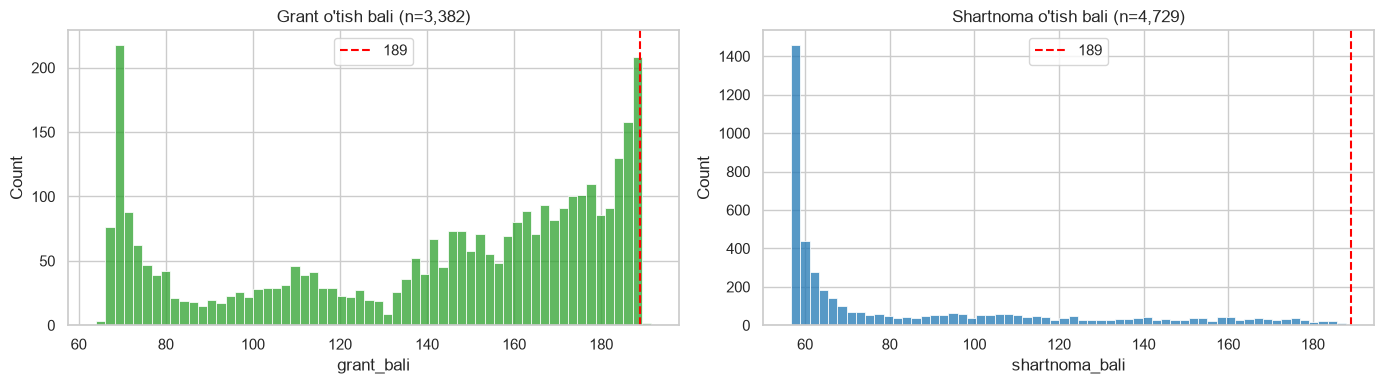

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(grant, bins=60, ax=axes[0], color='tab:green')
axes[0].set_title(f'Grant o\'tish bali (n={len(grant):,})')
sns.histplot(shartnoma, bins=60, ax=axes[1], color='tab:blue')
axes[1].set_title(f'Shartnoma o\'tish bali (n={len(shartnoma):,})')
for ax in axes:
    ax.axvline(189, color='red', ls='--', label='189')
    ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# Shartnoma bali eng past qiymatlari — minimal chegara bormi?
shartnoma.value_counts().sort_index().head(10)

shartnoma_bali
56.7    389
56.8    228
56.9    141
57.0     93
57.1     51
57.2     26
57.3     16
57.4     10
57.5     18
57.6     48
Name: count, dtype: int64

In [20]:
# 189 dan yuqori o'tish ballari
df[(df['grant_bali'] > 189) | (df['shartnoma_bali'] > 189)]

,Unnamed: 0,hudud,otm_nomi,yunalish_nomi,talim_tili,talim_shakli,grant_kvota_soni,shartnoma_kvota_soni,grant_bali,shartnoma_bali,asosiy_yunalish
4703,4703,Toshkent shahri,O‘zbekiston davlat konservatoriyasi,"Cholgʻu ijrochiligi: puflama va zarbli cholgʻular (fleyta, goboy, fagot)",O'zbekcha,Kunduzgi,1,7,191.5,134.9,Cholgʻu ijrochiligi: puflama va zarbli cholgʻular
4711,4711,Toshkent shahri,O‘zbekiston davlat konservatoriyasi,Cholgʻu ijrochiligi: puflama va zarbli cholgʻular (zarbli cholgʻular),O'zbekcha,Kunduzgi,1,4,190.0,96.1,Cholgʻu ijrochiligi: puflama va zarbli cholgʻular


In [21]:
# Grant bali doim shartnoma balidan yuqori bo'lishi kerak
ikkalasi = df[(df['grant_bali'] > 0) & (df['shartnoma_bali'] > 0)]
print('Ikkala ball ham bor qatorlar:  ', len(ikkalasi))
print('grant_bali < shartnoma_bali: ', (ikkalasi['grant_bali'] < ikkalasi['shartnoma_bali']).sum())
print('Farq (grant - shartnoma):')
(ikkalasi['grant_bali'] - ikkalasi['shartnoma_bali']).describe().round(1)

Ikkala ball ham bor qatorlar:   2550
grant_bali < shartnoma_bali:  0
Farq (grant - shartnoma):


count    2550.0
mean       44.4
std        34.2
min         0.5
25%        14.5
50%        34.9
75%        67.5
max       132.3
dtype: float64

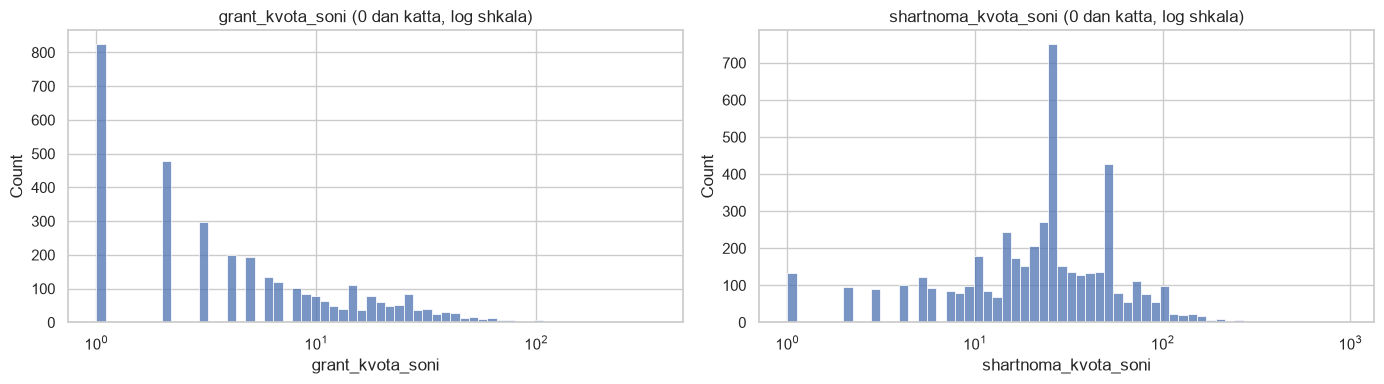

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['grant_kvota_soni', 'shartnoma_kvota_soni']):
    qiymat = df.loc[df[col] > 0, col]
    sns.histplot(qiymat, bins=60, ax=ax, log_scale=(True, False))
    ax.set_title(f'{col} (0 dan katta, log shkala)')
plt.tight_layout()
plt.show()

## 5. Kesimlar bo'yicha o'tish ballari

In [23]:
def ball_kesim(col):
    return (df.groupby(col)
              .agg(qatorlar=('otm_nomi', 'size'),
                   grant_kvota=('grant_kvota_soni', 'sum'),
                   shartnoma_kvota=('shartnoma_kvota_soni', 'sum'),
                   grant_bali_median=('grant_bali', lambda s: s[s > 0].median()),
                   shartnoma_bali_median=('shartnoma_bali', lambda s: s[s > 0].median()))
              .round(1)
              .sort_values('qatorlar', ascending=False))

ball_kesim('talim_shakli')

,qatorlar,grant_kvota,shartnoma_kvota,grant_bali_median,shartnoma_bali_median
talim_shakli,,,,,
Kunduzgi,4339,30958,103502,152.5,69.5
Kechki,900,3,24614,67.4,62.0
Masofaviy,444,4,19399,146.2,61.1
Dual,29,0,6750,NaN,56.7


In [24]:
ball_kesim('talim_tili')

,qatorlar,grant_kvota,shartnoma_kvota,grant_bali_median,shartnoma_bali_median
talim_tili,,,,,
O'zbekcha,4438,28023,131824,152.6,64.1
Русский,921,1962,18486,154.2,90.9
Qoraqalpoq,314,864,3450,149.6,64.3
Qozoq,19,80,190,84.9,61.8
Tadjik,14,24,268,104.7,63.9
Qirg'iz,3,8,35,73.2,57.5
Turkman,3,4,12,82.8,61.7


In [25]:
ball_kesim('hudud')

,qatorlar,grant_kvota,shartnoma_kvota,grant_bali_median,shartnoma_bali_median
hudud,,,,,
Toshkent shahri,1249,10138,42611,160.2,75.9
Qoraqalpog‘iston Respublikasi,732,1674,9127,147.9,65.3
Toshkent viloyati,498,1885,9546,156.7,67.8
Farg‘ona viloyati,475,2453,11770,152.5,63.1
Samarqand viloyati,460,3107,17814,146.5,72.7
Surxondaryo viloyati,392,1359,10015,151.1,61.6
Buxoro viloyati,376,2074,7183,152.4,65.2
Andijon viloyati,359,1994,11024,160.4,64.1
Qashqadaryo viloyati,323,1273,7533,140.9,61.2


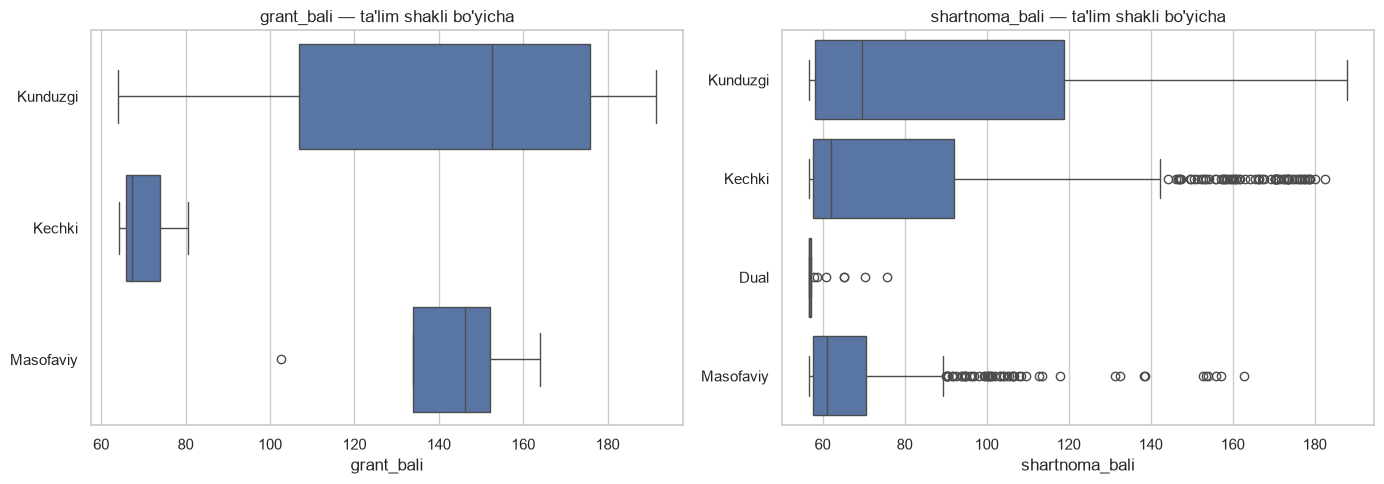

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['grant_bali', 'shartnoma_bali']):
    sns.boxplot(data=df[df[col] > 0], x=col, y='talim_shakli', ax=ax)
    ax.set_title(f'{col} — ta\'lim shakli bo\'yicha')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [27]:
print('Eng yuqori grant bali — top 10:')
df.nlargest(10, 'grant_bali')[['otm_nomi', 'yunalish_nomi', 'talim_tili', 'talim_shakli',
                               'grant_kvota_soni', 'grant_bali']]

Eng yuqori grant bali — top 10:


,otm_nomi,yunalish_nomi,talim_tili,talim_shakli,grant_kvota_soni,grant_bali
4703,O‘zbekiston davlat konservatoriyasi,"Cholgʻu ijrochiligi: puflama va zarbli cholgʻular (fleyta, goboy, fagot)",O'zbekcha,Kunduzgi,1,191.5
4711,O‘zbekiston davlat konservatoriyasi,Cholgʻu ijrochiligi: puflama va zarbli cholgʻular (zarbli cholgʻular),O'zbekcha,Kunduzgi,1,190.0
396,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Chimboy tumani),O'zbekcha,Kunduzgi,1,189.0
399,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Kegeyli tumani),Qoraqalpoq,Kunduzgi,3,189.0
401,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Moʻynoq tumani),Qoraqalpoq,Kunduzgi,2,189.0
402,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Nukus shahri),O'zbekcha,Kunduzgi,1,189.0
403,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Nukus shahri),Qoraqalpoq,Kunduzgi,2,189.0
410,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Qoraoʻzak tumani),Qoraqalpoq,Kunduzgi,1,189.0
412,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Shumanay tumani),Qoraqalpoq,Kunduzgi,4,189.0
416,Qoraqalpog‘iston tibbiyot instituti,Davolash ishi (Taxtakoʻpir tumani),Qoraqalpoq,Kunduzgi,2,189.0


## 6. Fanlar majmuasi bilan moslik

Abituriyentlar jadvali (`abts_prepared.csv`) OTM ga faqat **fanlar juftligi** orqali bog'lanadi. Shuning uchun har bir yo'nalishning fanlarini `Fanlar_majmuasi_2025-2026.xlsx` dan topish kerak.

In [28]:
fanlar = pd.read_excel('../data/raw/Fanlar_majmuasi_2025-2026.xlsx')
fanlar['kalit'] = fanlar['Bakalavriat taʼlim yoʻnalishlari nomi'].astype(str).str.strip().str.lower()
print('Fanlar majmuasidagi yo\'nalishlar:', fanlar['kalit'].nunique())

for nom, col in [('To\'liq nom', 'yunalish_nomi'), ('Qavssiz nom', 'asosiy_yunalish')]:
    mos = df[col].str.strip().str.lower().isin(fanlar['kalit'])
    print(f"{nom}: {mos.mean():.1%} qator mos keldi ({(~mos).sum()} ta mos kelmadi)")

Fanlar majmuasidagi yo'nalishlar: 218
To'liq nom: 72.5% qator mos keldi (1570 ta mos kelmadi)
Qavssiz nom: 87.2% qator mos keldi (729 ta mos kelmadi)


In [29]:
mos = df['asosiy_yunalish'].str.strip().str.lower().isin(fanlar['kalit'])
df.loc[~mos, 'asosiy_yunalish'].value_counts().head(20)

asosiy_yunalish
Cholgʻu ijrochiligi: xalq cholgʻulari                36
Sport faoliyati: voleybol                            27
Neftʼ va neft-gazni qayta ishlash texnologiyasi      25
Sport faoliyati: kurash                              25
Sport faoliyati: futbol                              24
Qayta tiklanuvchi energiya manbalari                 22
Cholgʻu ijrochiligi: estrada cholgʻulari             20
Cholgʻu ijrochiligi: puflama va zarbli cholgʻular    19
Dizayn: interyer dizayni                             17
Sport faoliyati: basketbol                           16
Sport faoliyati: dzyudo                              15
Sport faoliyati: qoʻl toʻpi                          15
Sport faoliyati: yengil atletika                     14
Rangtasvir: dastgohli                                14
Sport faoliyati: boks                                12
Vokal sanʼati: anʼanaviy xonandalik                  12
Sport faoliyati: erkin kurash                        11
Amaliy sanʼat: badiiy kulolchili

## 7. Xulosa

**Tuzilma.** 5 712 qator, 10 ustun: 14 hudud, 105 OTM, 1 096 yo'nalish nomi, 7 til, 4 shakl. `Unnamed: 0` — saqlashda qolib ketgan eski index, keraksiz.

**Belgilar va maqsad.** Kvotalar qabuldan oldin e'lon qilinadi, ya'ni ular belgi (feature) bo'la oladi. `grant_bali` va `shartnoma_bali` esa mandatdan keyin ma'lum bo'ladi — ular **maqsadli o'zgaruvchi**.

**Sifat.**
- Bo'sh qiymat yo'q, lekin `0` ball = "o'tish bali yo'q" (`fillna(0)` natijasi). Tekshiruv buni tasdiqladi: kvota 0 bo'lsa ball ham 0, va aksincha — istisnosiz. Model uchun 0 larni NaN deb qarash va bunday qatorlarni tegishli modeldan chiqarish kerak.
- 13 ta to'liq takror qator (asosan Buxoro davlat pedagogika institutidagi tuman kvotalari) — olib tashlash kerak.
- 1 ta kalit to'qnashuvi: TDIU `Davlat auditi`, O'zbekcha, Kunduzgi — ikki qator (shartnoma kvotasi 150 va 9), ball bir xil 176.4. Ehtimol turli kvota turlari; birlashtirish (kvotalarni qo'shish) mumkin.
- 151 qatorda na grant, na shartnoma kvotasi bor — bu yo'nalishlar bu yil qabul qilmagan, olib tashlash kerak.

**O'tish ballari.**
- Grant bali (3 382 qator): mediana 152.4, oraliq 64–191.5. Shartnoma bali (4 729 qator): mediana 65.5, oraliq 56.7–187.9.
- Shartnoma bali pastdan **56.7** da qirqilgan (389 qator aynan 56.7) — bu minimal o'tish chegarasi, abituriyentlar jadvalidagi eng past ball bilan bir xil.
- Grant bali hech qachon shartnoma balidan past emas (2 550 qatorda farq 0.5–132.3, mediana 34.9).
- 2 ta grant bali 189 dan yuqori (Konservatoriya, 191.5 va 190.0) — qo'shimcha ball hisobiga.

**Kesimlar.**
- Grant deyarli faqat **Kunduzgi** shaklda: Kechki 3, Masofaviy 4, Dual 0 ta grant o'rni. Grant modeli amalda Kunduzgi uchun bo'ladi.
- Rus tilidagi guruhlarda shartnoma bali ancha yuqori (mediana 90.9, o'zbekchada 64.1).
- Kichik tillar (Qozoq, Tojik, Qirg'iz, Turkman) juda kam qator — modelda siyrak kategoriyalar.

**Yo'nalish nomlari.**
- 934 ta nomda qavs bor, shundan 756 tasi tuman maqsadli kvotasi (`Davolash ishi (Kitob tumani)`). Qavsni olib tashlasak 1 096 → 342 ta asosiy yo'nalish qoladi.
- Fanlar majmuasi bilan moslik: to'liq nom bo'yicha 72.5%, qavssiz nom bo'yicha **87.2%**. Mos kelmaganlar asosan ixtisosliklar (`Sport faoliyati: voleybol`, `Cholgʻu ijrochiligi: ...`, `Dizayn: ...`) — ular ko'pincha kasbiy (ijodiy) imtihonli yo'nalishlar va qo'lda moslashtirish kerak.

### Keyingi qadam (Data Preparation)
1. `Unnamed: 0` ni olib tashlash, 13 ta to'liq takrorni o'chirish, TDIU to'qnashuvini hal qilish.
2. Kvotasi umuman yo'q 151 qatorni olib tashlash; 0 ballarni NaN ga almashtirish.
3. `asosiy_yunalish` va `tuman_kvotasi` belgilarini yaratish.
4. Fanlar majmuasi bilan moslikni 100% ga yetkazish (ixtisosliklar uchun qo'lda moslashtirish) — shunda har bir yo'nalishga `1-fan`/`2-fan` biriktirib, abituriyentlar jadvali bilan fanlar juftligi orqali bog'lash mumkin bo'ladi.